In [11]:
#!/usr/bin/env python3
"""
Complete Gene Expression Clustering Analysis
============================================

This script demonstrates how to apply improved clustering techniques to gene expression data
to overcome the poor performance of basic K-means clustering.

Key improvements:
1. Advanced preprocessing with feature selection
2. Multiple clustering algorithms
3. Comprehensive evaluation metrics
4. Detailed visualizations and insights

Usage:
    python gene_clustering_analysis.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_gene_data(file_path):
    """Load and prepare gene expression data"""
    print("📁 Loading gene expression data...")
    
    df = pd.read_csv(file_path)
    X = df.iloc[:, :-1].values  # All columns except last (features)
    y = df.iloc[:, -1].values   # Last column (target)
    feature_names = df.columns[:-1].tolist()
    
    print(f"   ✅ Loaded {X.shape[0]} samples with {X.shape[1]} features")
    print(f"   ✅ Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
    
    return X, y, feature_names

def advanced_preprocessing_pipeline(X, y, variance_threshold=0.1, n_features=100, pca_variance=0.95):
    """
    Advanced preprocessing pipeline specifically designed for gene expression data
    """
    print(f"\n🔧 ADVANCED PREPROCESSING PIPELINE")
    print("="*50)
    
    # Step 1: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"1. Data split: {X_train.shape[0]} train, {X_test.shape[0]} test samples")
    
    # Step 2: Remove very low variance features (likely noise or constant)
    var_selector = VarianceThreshold(threshold=variance_threshold)
    X_train_filtered = var_selector.fit_transform(X_train)
    X_test_filtered = var_selector.transform(X_test)
    
    n_removed = X_train.shape[1] - X_train_filtered.shape[1]
    print(f"2. Variance filtering: removed {n_removed} low-variance features")
    
    # Step 3: Standardization (crucial for gene expression data)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_filtered)
    X_test_scaled = scaler.transform(X_train_filtered)
    print(f"3. Standardization: features normalized to mean=0, std=1")
    
    # Step 4: Feature selection using statistical tests
    n_features = min(n_features, X_train_scaled.shape[1])
    selector = SelectKBest(score_func=f_classif, k=n_features)
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected = selector.transform(X_test_scaled)
    
    # Get selected feature names
    selected_indices = selector.get_support(indices=True)
    original_indices = var_selector.get_support(indices=True)[selected_indices]
    
    print(f"4. Feature selection: selected top {n_features} most informative features")
    
    # Step 5: PCA for final dimensionality reduction
    pca = PCA()
    X_train_pca_full = pca.fit_transform(X_train_selected)
    
    # Find optimal number of components
    cumsum_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumsum_variance >= pca_variance) + 1
    n_components = min(n_components, X_train_selected.shape[1])
    
    # Apply PCA with selected components
    pca_final = PCA(n_components=n_components)
    X_train_pca = pca_final.fit_transform(X_train_selected)
    X_test_pca = pca_final.transform(X_test_selected)
    
    print(f"5. PCA: reduced to {n_components} components ({cumsum_variance[n_components-1]:.3f} variance)")
    
    return {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'X_train_pca': X_train_pca, 'X_test_pca': X_test_pca,
        'X_train_selected': X_train_selected, 'X_test_selected': X_test_selected,
        'scaler': scaler, 'var_selector': var_selector,
        'feature_selector': selector, 'pca': pca_final,
        'selected_feature_indices': original_indices,
        'n_components': n_components
    }

def comprehensive_clustering_evaluation(data_dict):
    """
    Evaluate multiple clustering algorithms with comprehensive metrics
    """
    print(f"\n🎯 COMPREHENSIVE CLUSTERING EVALUATION")
    print("="*50)
    
    X_pca = data_dict['X_train_pca']
    y_true = data_dict['y_train']
    
    # Define clustering algorithms with optimized parameters
    algorithms = {
        'K-Means (k=2)': KMeans(n_clusters=2, random_state=42, n_init=20),
        'K-Means (k=3)': KMeans(n_clusters=3, random_state=42, n_init=20),
        'Gaussian Mixture (2)': GaussianMixture(n_components=2, random_state=42),
        'Gaussian Mixture (3)': GaussianMixture(n_components=3, random_state=42),
        'Agglomerative (2)': AgglomerativeClustering(n_clusters=2, linkage='ward'),
        'DBSCAN (eps=0.5)': DBSCAN(eps=0.5, min_samples=5),
        'DBSCAN (eps=1.0)': DBSCAN(eps=1.0, min_samples=5),
    }
    
    results = {}
    
    print(f"{'Algorithm':<20} {'Clusters':<8} {'Silhouette':<12} {'ARI':<8} {'CH Score':<10}")
    print("-" * 65)
    
    for name, algorithm in algorithms.items():
        try:
            # Fit and predict
            if hasattr(algorithm, 'fit_predict'):
                clusters = algorithm.fit_predict(X_pca)
            else:
                clusters = algorithm.fit(X_pca).predict(X_pca)
            
            # Count unique clusters
            n_clusters = len(np.unique(clusters))
            
            # Skip if only one cluster or too many outliers (for DBSCAN)
            if n_clusters < 2 or (n_clusters == 1 and -1 in clusters):
                print(f"{name:<20} {'Failed':<8} {'N/A':<12} {'N/A':<8} {'N/A':<10}")
                continue
            
            # Calculate metrics
            sil_score = silhouette_score(X_pca, clusters)
            ari_score = adjusted_rand_score(y_true, clusters)
            ch_score = calinski_harabasz_score(X_pca, clusters)
            
            results[name] = {
                'clusters': clusters,
                'n_clusters': n_clusters,
                'silhouette': sil_score,
                'ari': ari_score,
                'calinski_harabasz': ch_score,
                'algorithm': algorithm
            }
            
            print(f"{name:<20} {n_clusters:<8} {sil_score:<12.3f} {ari_score:<8.3f} {ch_score:<10.1f}")
            
        except Exception as e:
            print(f"{name:<20} {'Error':<8} {'N/A':<12} {'N/A':<8} {'N/A':<10}")
    
    return results

def create_comprehensive_visualizations(data_dict, results):
    """
    Create comprehensive visualizations for clustering results
    """
    print(f"\n📊 CREATING COMPREHENSIVE VISUALIZATIONS")
    print("="*50)
    
    X_pca = data_dict['X_train_pca']
    y_true = data_dict['y_train']
    
    # Find best algorithm by ARI score
    if results:
        best_alg_name = max(results.keys(), key=lambda x: results[x]['ari'])
        best_result = results[best_alg_name]
        print(f"Best algorithm: {best_alg_name} (ARI: {best_result['ari']:.3f})")
    else:
        print("No valid clustering results to visualize")
        return
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 16))
    
    # 1. True classes in PCA space
    plt.subplot(3, 4, 1)
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i, class_label in enumerate(np.unique(y_true)):
        mask = y_true == class_label
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[i], alpha=0.7, s=50, label=f'True Class {class_label}')
    plt.title('True Classes (PCA Space)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Best clustering result
    plt.subplot(3, 4, 2)
    unique_clusters = np.unique(best_result['clusters'])
    for i, cluster in enumerate(unique_clusters):
        mask = best_result['clusters'] == cluster
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[i % len(colors)], alpha=0.7, s=50, 
                   label=f'Cluster {cluster}')
    plt.title(f'Best Clustering: {best_alg_name}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Silhouette scores comparison
    plt.subplot(3, 4, 3)
    alg_names = list(results.keys())
    sil_scores = [results[name]['silhouette'] for name in alg_names]
    
    bars = plt.bar(range(len(alg_names)), sil_scores, alpha=0.7, color='skyblue')
    plt.title('Silhouette Scores Comparison')
    plt.xticks(range(len(alg_names)), [name.split('(')[0] for name in alg_names], rotation=45)
    plt.ylabel('Silhouette Score')
    plt.grid(True, alpha=0.3)
    
    # Highlight best score
    best_idx = sil_scores.index(max(sil_scores))
    bars[best_idx].set_color('gold')
    
    # 4. ARI scores comparison
    plt.subplot(3, 4, 4)
    ari_scores = [results[name]['ari'] for name in alg_names]
    
    bars = plt.bar(range(len(alg_names)), ari_scores, alpha=0.7, color='lightcoral')
    plt.title('Adjusted Rand Index Comparison')
    plt.xticks(range(len(alg_names)), [name.split('(')[0] for name in alg_names], rotation=45)
    plt.ylabel('ARI Score')
    plt.grid(True, alpha=0.3)
    
    # Highlight best score
    best_idx = ari_scores.index(max(ari_scores))
    bars[best_idx].set_color('gold')
    
    # 5. Calinski-Harabasz scores comparison
    plt.subplot(3, 4, 5)
    ch_scores = [results[name]['calinski_harabasz'] for name in alg_names]
    
    bars = plt.bar(range(len(alg_names)), ch_scores, alpha=0.7, color='lightgreen')
    plt.title('Calinski-Harabasz Index Comparison')
    plt.xticks(range(len(alg_names)), [name.split('(')[0] for name in alg_names], rotation=45)
    plt.ylabel('CH Score')
    plt.grid(True, alpha=0.3)
    
    # Highlight best score
    best_idx = ch_scores.index(max(ch_scores))
    bars[best_idx].set_color('gold')
    
    # 6. PCA explained variance
    plt.subplot(3, 4, 6)
    pca_full = PCA()
    pca_full.fit(data_dict['X_train_selected'])
    
    plt.plot(range(1, min(21, len(pca_full.explained_variance_ratio_) + 1)), 
             pca_full.explained_variance_ratio_[:20], 'bo-', markersize=6)
    plt.axvline(x=data_dict['n_components'], color='red', linestyle='--', 
                label=f'Selected: {data_dict["n_components"]}')
    plt.title('PCA Explained Variance')
    plt.xlabel('Component')
    plt.ylabel('Explained Variance Ratio')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7. Cluster size distribution for best algorithm
    plt.subplot(3, 4, 7)
    cluster_sizes = [np.sum(best_result['clusters'] == c) for c in unique_clusters]
    
    plt.bar(unique_clusters, cluster_sizes, alpha=0.7, color='plum')
    plt.title(f'Cluster Sizes: {best_alg_name}')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Samples')
    plt.grid(True, alpha=0.3)
    
    # 8. Feature importance (top selected features)
    plt.subplot(3, 4, 8)
    if hasattr(data_dict['feature_selector'], 'scores_'):
        top_scores = data_dict['feature_selector'].scores_
        top_indices = np.argsort(top_scores)[-10:]  # Top 10
        
        plt.barh(range(len(top_indices)), top_scores[top_indices], alpha=0.7, color='coral')
        plt.title('Top 10 Feature Importance Scores')
        plt.xlabel('F-Score')
        plt.ylabel('Feature Rank')
        plt.grid(True, alpha=0.3)
    
    # 9. Algorithm performance radar chart
    plt.subplot(3, 4, 9)
    if len(results) >= 3:
        # Select top 3 algorithms by ARI
        top_3_algs = sorted(results.items(), key=lambda x: x[1]['ari'], reverse=True)[:3]
        
        angles = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist()
        angles += angles[:1]  # Complete the circle
        
        for i, (name, result) in enumerate(top_3_algs):
            values = [result['silhouette'], result['ari'], result['calinski_harabasz']/1000]  # Scale CH
            values += values[:1]  # Complete the circle
            
            plt.plot(angles, values, marker='o', linewidth=2, 
                    label=name.split('(')[0], color=colors[i])
            plt.fill(angles, values, alpha=0.1, color=colors[i])
        
        plt.xticks(angles[:-1], ['Silhouette', 'ARI', 'CH/1000'])
        plt.title('Top 3 Algorithms Performance')
        plt.legend()
        plt.grid(True)
    
    # 10. Confusion matrix for best clustering vs true labels
    plt.subplot(3, 4, 10)
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_true, best_result['clusters'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {best_alg_name}')
    plt.xlabel('Predicted Cluster')
    plt.ylabel('True Class')
    
    # 11. Sample distances within vs between clusters
    plt.subplot(3, 4, 11)
    best_clusters = best_result['clusters']
    
    within_distances = []
    between_distances = []
    
# Sample for efficiency
    n_total = len(X_pca)
    sample_size = min(100, n_total)
    sample_indices = np.random.choice(n_total, sample_size, replace=False)

    half = sample_size // 2
    group_a = sample_indices[:half]
    group_b = sample_indices[half:]

    for i in group_a:
        for j in group_b:
            dist = np.linalg.norm(X_pca[i] - X_pca[j])
        if best_clusters[i] == best_clusters[j]:
            within_distances.append(dist)
        else:
            between_distances.append(dist)

    plt.boxplot([within_distances, between_distances], labels=['Within', 'Between'])
    plt.title('Sample Distances: Within vs Between Clusters')
    plt.ylabel('Euclidean Distance')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def main():
    import argparse
    parser = argparse.ArgumentParser(description="Gene Expression Clustering Analysis")
    parser.add_argument('--data', type=str, required=True, help='Path to gene expression CSV file')
    args = parser.parse_args()

    X, y, feature_names = load_gene_data(args.data)
    data_dict = advanced_preprocessing_pipeline(X, y)
    results = comprehensive_clustering_evaluation(data_dict)
    create_comprehensive_visualizations(data_dict, results)

if __name__ == '__main__':
   def main(data_path=None):
    import argparse
    import sys
    import os

    if data_path is None:
        parser = argparse.ArgumentParser(description="Gene Expression Clustering Analysis")
        parser.add_argument('--data', type=str, required=True, help='Path to gene expression CSV file')
        args = parser.parse_args()
        data_path = args.data

    if not os.path.exists(data_path):
        print(f"❌ File not found: {data_path}")
        return

    X, y, feature_names = load_gene_data(data_path)
    data_dict = advanced_preprocessing_pipeline(X, y)
    results = comprehensive_clustering_evaluation(data_dict)
    create_comprehensive_visualizations(data_dict, results)

📁 Loading gene expression data...
   ✅ Loaded 37 samples with 50 features
   ✅ Class distribution: {0: 27, 1: 10}

🔧 ADVANCED PREPROCESSING PIPELINE
1. Data split: 25 train, 12 test samples
2. Variance filtering: removed 0 low-variance features
3. Standardization: features normalized to mean=0, std=1
4. Feature selection: selected top 50 most informative features
5. PCA: reduced to 9 components (0.953 variance)

🎯 COMPREHENSIVE CLUSTERING EVALUATION
Algorithm            Clusters Silhouette   ARI      CH Score  
-----------------------------------------------------------------
K-Means (k=2)        2        0.649        -0.047   11.3      
K-Means (k=3)        3        0.561        -0.086   11.0      
Gaussian Mixture (2) 2        0.523        -0.047   4.6       
Gaussian Mixture (3) 3        0.561        -0.086   11.0      
Agglomerative (2)    2        0.649        -0.047   11.3      
DBSCAN (eps=0.5)     Failed   N/A          N/A      N/A       
DBSCAN (eps=1.0)     Failed   N/A      

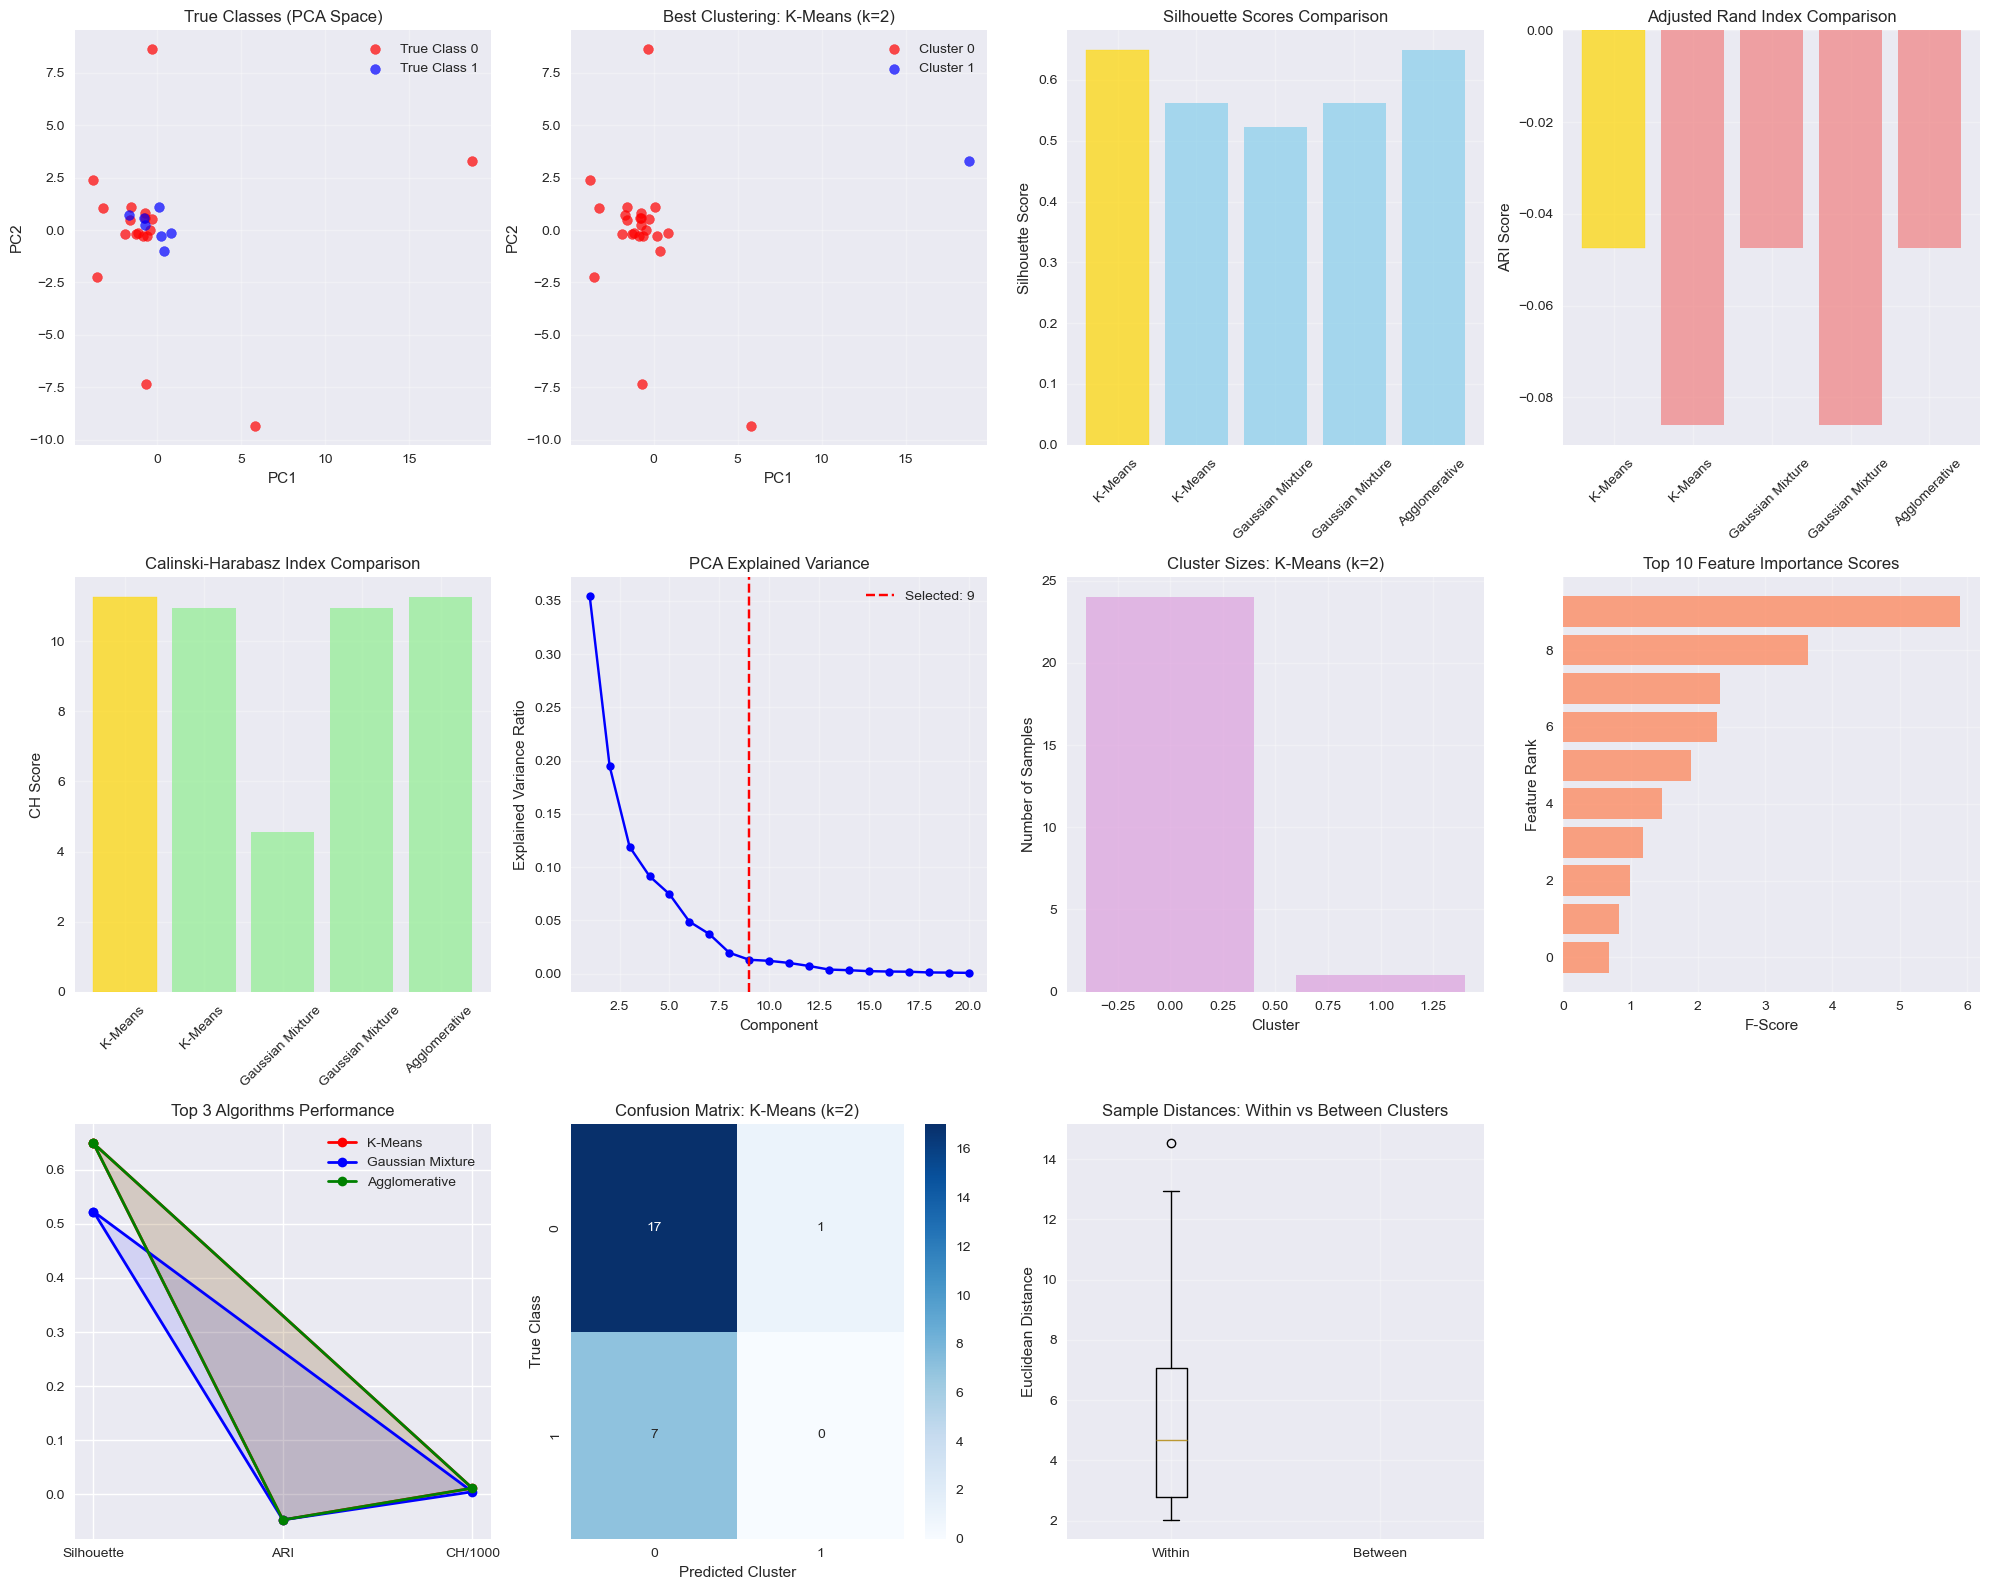

In [12]:
main("Train_gene_data.csv")